/tmp/ipython-input-928/2296127798.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stockData = yf.download(stocks, start=start, end=end)['Close']
[*********************100%***********************]  6 of 6 completed


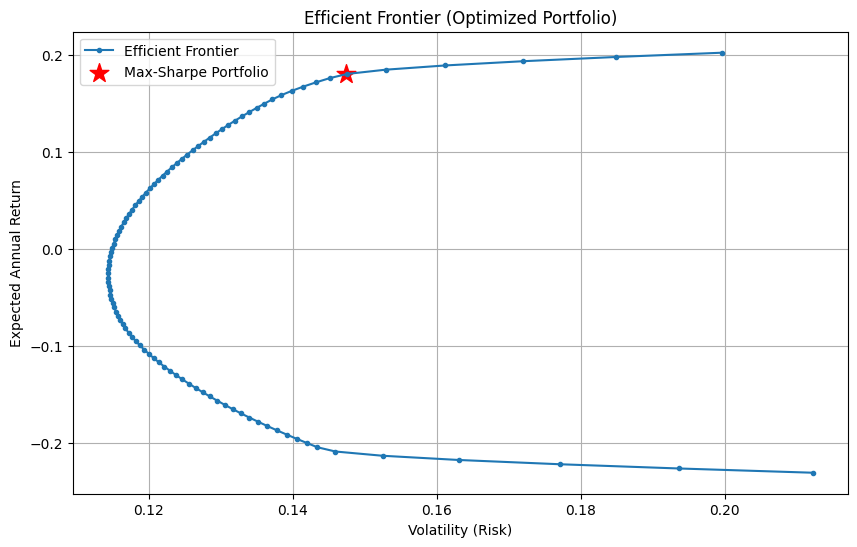

--- Portfolio Results ---
Optimized Weights: {'RELIANCE': np.float64(0.0), 'TCS': np.float64(0.51), 'HDFCBANK': np.float64(0.0), 'ICICIBANK': np.float64(0.0), 'INFY': np.float64(0.49), 'ITC': np.float64(0.0)}
95% Value at Risk (VaR): ₹8748.79
95% Conditional VaR (CVaR): ₹14421.63


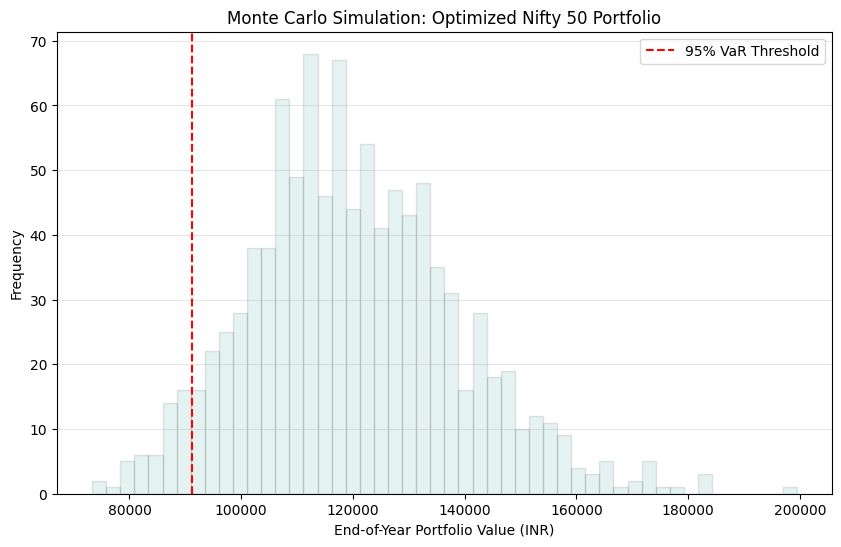

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf
from scipy.optimize import minimize

# import data
def get_data(stocks, start, end):
    stockData = yf.download(stocks, start=start, end=end)['Close']
    returns = stockData.pct_change().dropna()
    return returns.mean(), returns.cov()

stockList = ['RELIANCE', 'TCS', 'HDFCBANK', 'ICICIBANK', 'INFY', 'ITC']
stocks = [s + '.NS' for s in stockList]

endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365)
meanReturns, covMatrix = get_data(stocks, startDate, endDate)

def portfolio_stats(weights, meanReturns, covMatrix):
    p_returns = np.sum(meanReturns * weights) * 252
    p_volatility = np.sqrt(np.dot(weights.T, np.dot(covMatrix * 252, weights)))
    p_sharpe = p_returns / p_volatility
    return p_returns, p_volatility, p_sharpe

def min_func_sharpe(weights):
  return -portfolio_stats(weights, meanReturns, covMatrix)[2]

cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(len(stocks)))
initial_guess = len(stocks) * [1./len(stocks)]

optimized_results = minimize(min_func_sharpe, initial_guess, method='SLSQP', bounds=bounds, constraints=cons)
weights = optimized_results.x

def portfolio_performance(weights, meanReturns, covMatrix):
    ret = np.sum(meanReturns * weights) * 252
    vol = np.sqrt(np.dot(weights.T, np.dot(covMatrix * 252, weights)))
    return ret, vol

def min_variance(weights):
    return portfolio_performance(weights, meanReturns, covMatrix)[1]

target_returns = np.linspace(meanReturns.min()*252, meanReturns.max()*252,100)

efficient_vols = []
efficient_rets = []

for tr in target_returns:
    cons = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: portfolio_performance(x, meanReturns, covMatrix)[0] - tr}
    )
    bounds = tuple((0, 1) for _ in range(len(stocks)))
    initial = np.array(len(stocks) * [1./len(stocks)])

    result = minimize(min_variance, initial, method='SLSQP', bounds=bounds, constraints=cons)

    efficient_vols.append(result.fun)
    efficient_rets.append(tr)

plt.figure(figsize=(10, 6))
plt.plot(efficient_vols, efficient_rets, 'o-', markersize=3, label='Efficient Frontier')

opt_ret, opt_vol = portfolio_performance(weights, meanReturns, covMatrix)
plt.scatter(opt_vol, opt_ret, c='red', marker='*', s=200, label='Max-Sharpe Portfolio')

plt.title('Efficient Frontier (Optimized Portfolio)')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Annual Return')
plt.legend()
plt.grid(True)
plt.show()

# Monte Carlo
mc_sims = 1000
T = 252
initialPortfolio = 100000

portfolio_sims = np.zeros((T, mc_sims))
L = np.linalg.cholesky(covMatrix)

for i in range(mc_sims):
    Z = np.random.normal(size=(T, len(weights)))
    # correlated returns
    dailyReturns = meanReturns.values + Z @ L.T
    # portfolio value path
    portfolio_sims[:, i] = np.cumprod(1 + dailyReturns @ weights) * initialPortfolio

final_values = portfolio_sims[-1, :]
at_risk = initialPortfolio - final_values
var_95 = np.percentile(at_risk, 95)
cvar_95 = at_risk[at_risk > var_95].mean()


print(f'--- Portfolio Results ---')
print(f'Optimized Weights: {dict(zip(stockList, np.round(weights, 3)))}')
print(f'95% Value at Risk (VaR): ₹{var_95:.2f}')
print(f'95% Conditional VaR (CVaR): ₹{cvar_95:.2f}')

# Plot
plt.figure(figsize=(10, 6))
plt.hist(final_values, bins=50, color='teal', alpha=0.1, edgecolor='black')
plt.axvline(initialPortfolio - var_95, color='red', linestyle='--', label=f'95% VaR Threshold')
plt.title('Monte Carlo Simulation: Optimized Nifty 50 Portfolio')
plt.xlabel('End-of-Year Portfolio Value (INR)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()